## Chapter 5: Pre-training LLM on unlabeled data

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/02.webp" width=400px>

In [1]:
# printing package versions used in the notebook
from importlib.metadata import version

pkgs = [
    "torch",
    "matplotlib",
    "numpy",
    "tiktoken",
    "tensorflow"        # for loading OpenAI's weights
]

for pkg in pkgs:
    print(f"{pkg} version: {version(pkg)}")

torch version: 2.9.1+cu130
matplotlib version: 3.10.7
numpy version: 2.3.5
tiktoken version: 0.12.0
tensorflow version: 2.20.0


In [2]:
import torch

print(f"Is GPU available: {torch.cuda.is_available()}")

Is GPU available: True


### 5.1 Evaluating text generation models

#### 5.1.1 Utility function to encode and decode text

In [3]:
# import the GPT-2 model architecture from gpt2.py file
from gpt2 import GPTModel

GPT2_CONFIG_124M = {
    "vocab_size": 50257,            # Vocabulary size
    "contextWindow_len": 256,       # Shortened context length (orig: 1024)
    "embedding_dim": 768,           # Embedding dimension
    "num_heads": 12,                # Number of attention heads
    "num_transformerLayers": 12,    # Number of layers
    "dropout_rate": 0.1,            # Dropout rate
    "qkv_bias": False               # Query-Key-Value bias
}

torch.manual_seed(123)
gpt2_model = GPTModel(GPT2_CONFIG_124M)

gpt2_model.eval();      # this command will print the model architecture if the semicolon is removed

- dropout of 0.1 is above, but it's relatively common to train LLMs without dropout nowadays
- Modern LLMs also don't use bias vectors in the `nn.Linear` layers for the query, key, and value matrices (unlike earlier GPT models), which is achieved by setting `"qkv_bias": False`
- the context length (`context_length`) is reduced to only 256 tokens to reduce the computational resource requirements for training the model, whereas the original 124 million parameter GPT-2 model used 1024 tokens

- we use the `generate_text_tokens` function from the gpt2.py file to generate text
- In addition, two utility functions, `text_to_token_ids` and `token_ids_to_text`, for converting between token and text representations are defined

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/03.webp" width=500px>

In [4]:
def text_to_token_ids(input_sentence, tokenizer):
    encoded_text = tokenizer.encode(input_sentence, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded_text).unsqueeze(0)      # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    decoded_list = token_ids.squeeze(0).tolist()    # remove batch dimension
    return tokenizer.decode(decoded_list)

In [5]:
import tiktoken
from gpt2 import generate_text_tokens

sample_input = "Every day holds a"
gpt2_tokenizer = tiktoken.get_encoding("gpt2")

# encode input sentence into token ids contained in tensor using utility function
encoded_text = text_to_token_ids(sample_input, gpt2_tokenizer)
print(f"The encoded token ids for input sentence is of shape {encoded_text.shape} and contains: \n{encoded_text}\n")

generated_tokens = generate_text_tokens(
    model = gpt2_model,
    input_ids = encoded_text,
    max_new_tokens = 10, 
    context_window = GPT2_CONFIG_124M["contextWindow_len"]
)

# decode token ids into text using utility function
decoded_sentence = token_ids_to_text(generated_tokens, gpt2_tokenizer)
print(f"The decoded sentence for tokens generated from models are: \n{decoded_sentence}")

The encoded token ids for input sentence is of shape torch.Size([1, 4]) and contains: 
tensor([[6109, 1110, 6622,  257]])

The decoded sentence for tokens generated from models are: 
Every day holds a Directionsolkien LGBT TackleACTLab Transactionß sleeves stren


#### 5.1.2 Calculating text genration loss using cross-entropy and perplexity

- Consider having an `sample_input_tokens` tensor containing the token IDs for 2 training examples (rows)
- Corresponding to the `sample_input_tokens`, the `sample_target_tokens` contain the desired token IDs that is expected to be genearted by the model
- Notice that the `sample_target_tokens` are the `sample_input_tokens` shifted by 1 position, similar to when using the data loader

In [6]:
# random sample data for loss computation
sample_input_tokens = torch.tensor([
    [16833, 3626, 6100],    # ["every effort moves",
    [40,    1107, 588]      #  "I really like"]
])

sample_target_tokens = torch.tensor([
    [3626, 6100, 345  ],    # [" effort moves you",
    [1107,  588, 11311]     #  " really like chocolate"]
])

- Feeding the `sample_input_tokens` to the model, we obtain the logits vector for the 2 input examples that consist of 3 tokens each
- Each of the tokens is a 50,257-dimensional vector corresponding to the size of the vocabulary
- Applying the softmax function, we can turn the logits tensor into a tensor of the same dimension containing probability scores 

- The figure below, using a very small vocabulary for illustration purposes, outlines how to convert the probability scores back into text

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/04.webp" width=500px>

- Applying the `argmax` function to convert the probability scores into predicted token IDs
- The softmax function above produced a 50,257-dimensional vector for each token, the `argmax` function returns the position of the highest probability score in this vector, which is the predicted token ID for the given token

In [7]:
with torch.no_grad():
    logits = gpt2_model(sample_input_tokens)

print(f"Logits generated by model are(y tensor): \n{logits}\n")

token_probabilities = torch.softmax(logits, dim=-1)
print(f"The probabilities for each tokens in vocabulary are: \n{token_probabilities}\n")

next_tokens = torch.argmax(token_probabilities, dim=-1, keepdim=True)
print(f"The next token ids generated by model are: \n{next_tokens}")

Logits generated by model are(y tensor): 
tensor([[[ 0.1113, -0.1057, -0.3666,  ...,  0.2843, -0.8824,  0.1074],
         [-0.6109, -0.5167, -0.7613,  ...,  0.5450, -1.0319, -0.2175],
         [ 0.5707, -0.6459, -0.0701,  ...,  0.7419, -0.1806, -0.2217]],

        [[-0.2968,  0.1949, -0.1649,  ..., -0.4867,  0.7218, -0.1714],
         [-0.8375,  0.0612, -0.4641,  ...,  0.2327, -0.3889, -0.0770],
         [ 0.5614,  0.6919,  0.8915,  ..., -0.9472,  1.2411, -0.2056]]])

The probabilities for each tokens in vocabulary are: 
tensor([[[1.8849e-05, 1.5172e-05, 1.1687e-05,  ..., 2.2409e-05,
          6.9776e-06, 1.8776e-05],
         [9.1569e-06, 1.0062e-05, 7.8786e-06,  ..., 2.9090e-05,
          6.0103e-06, 1.3571e-05],
         [2.9877e-05, 8.8507e-06, 1.5741e-05,  ..., 3.5456e-05,
          1.4094e-05, 1.3526e-05]],

        [[1.2561e-05, 2.0538e-05, 1.4332e-05,  ..., 1.0389e-05,
          3.4784e-05, 1.4239e-05],
         [7.2731e-06, 1.7864e-05, 1.0565e-05,  ..., 2.1206e-05,
          1

In [8]:
# the next text generated for each position by model for input sentence 1 ("every effort moves")
sample_index = 0

print(f"Expected text generation(target): {token_ids_to_text(sample_input_tokens[sample_index], gpt2_tokenizer)}")
# flatten function reshapes tensor into 1D for the start and end dimensions mentioned(takes entire tensor[0,-1] by default)
print(f"Actual text generated by model(y): {token_ids_to_text(next_tokens[sample_index].flatten(), gpt2_tokenizer)}")


Expected text generation(target): every effort moves
Actual text generated by model(y):  Armed heNetflix


- model have generated random text since it doesn't have information from training to predict
- To train the model, we need to know how far it is away from the correct predictions (targets)

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/06.webp" width=500px>

In [9]:
# computing cross entropy loss
# cross entropy loss is a negative avergage log likelihood of y(computed by model) and target

target_y1_probabilities = token_probabilities[sample_index, [0, 1, 2], sample_target_tokens[sample_index]]
print(f"The probabilities generated for target token positions of input 1 are: {target_y1_probabilities}\n")

sample_index = 1        # for input sentence 2
target_y2_probabilities = token_probabilities[sample_index, [0, 1, 2], sample_target_tokens[sample_index]]
print(f"The probabilities generated for target token positions of input 2 are: {target_y2_probabilities}")

The probabilities generated for target token positions of input 1 are: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])

The probabilities generated for target token positions of input 2 are: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


- In order to acheive these token ids in output, we need to maximize all these values bringing them close to a probability of 1
- In mathematical optimization, it is easier to maximize the logarithm of the probability score than the probability score itself
- The following lecture explains this concept with more details: [L8.2 Logistic Regression Loss Function](https://www.youtube.com/watch?v=GxJe0DZvydM)

In [10]:
torch.cat((target_y1_probabilities, target_y2_probabilities))

tensor([7.4540e-05, 3.1061e-05, 1.1563e-05, 1.0337e-05, 5.6776e-05, 4.7559e-06])

In [11]:
# finding log of the token probabilities
log_probabilities = torch.log(torch.cat((target_y1_probabilities, target_y2_probabilities)))
print(f"The log probabilities of target position tokens(y1, y2) are: {log_probabilities}")

The log probabilities of target position tokens(y1, y2) are: tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [12]:
# finding average of the log probabilities
log_mean = torch.mean(log_probabilities)
print(f"Average of log probabilities is: {log_mean}")

Average of log probabilities is: -10.793964385986328


- The goal is to make this average log probability as large as possible by optimizing the model weights
- Due to the log, the largest possible value is 0, and we are currently far away from 0

- In deep learning, instead of maximizing the average log-probability, it's a standard convention to minimize the *negative* average log-probability value; in our case, instead of maximizing -10.7722 so that it approaches 0, in deep learning, we would minimize 10.7722 so that it approaches 0
- The value negative of -10.7722, i.e., 10.7722, is also called cross-entropy loss in deep learning

In [13]:
# finding negative average of the log probabilities to arrive at cross entropy loss
negative_mean = -1 * log_mean
print(f"cross entropy loss value is: {negative_mean}")

cross entropy loss value is: 10.793964385986328


- PyTorch already implements a `cross_entropy` function that carries out the steps to compute cross entropy loss

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/07.webp" width=400px>

In [14]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print(f"dimensions of logits tensor is: {logits.shape}")
# Targets have shape (batch_size, num_tokens)
print(f"dimensions of target tensor is: {sample_target_tokens.shape}")

dimensions of logits tensor is: torch.Size([2, 3, 50257])
dimensions of target tensor is: torch.Size([2, 3])


In [15]:
# flattening tensors to give a single input instead of batch
logits_flattened = logits.flatten(0, 1)
sample_target_flattened = sample_target_tokens.flatten(0, 1)

print(f"dimensions of logits tensor after flattening is: {logits_flattened.shape}")
print(f"dimensions of target tensor after flattening is: {sample_target_flattened.shape}")

dimensions of logits tensor after flattening is: torch.Size([6, 50257])
dimensions of target tensor after flattening is: torch.Size([6])


In [16]:
# cross entropy loss can be calculated using pytorch function which is an optimized version for function calls
cross_entropy_loss = torch.nn.functional.cross_entropy(logits_flattened, sample_target_flattened)
print(f"Cross entropy loss value is: {cross_entropy_loss}")

Cross entropy loss value is: 10.793964385986328


- A concept related to the cross-entropy loss is the perplexity of an LLM
- The perplexity is simply the exponential of the cross-entropy loss

In [17]:
# computing preplexity for given cross entropy loss 
perplexity = torch.exp(cross_entropy_loss)
print(f"The perplexity value is: {perplexity}")

The perplexity value is: 48725.8203125


- The perplexity is often considered more interpretable because it can be understood as the effective vocabulary size that the model is uncertain about at each step/position (in the example above, 48,725 words or tokens are equally likely to come at next positions each time)
- In other words, perplexity provides a measure of how well the probability distribution predicted by the model matches the actual distribution of the words in the dataset
- Similar to the loss, a lower perplexity indicates that the model predictions are closer to the actual distribution

#### 5.1.3 Calculating loss for training and validation sets

In [18]:
# downloading dataset 'the verdict'
import os
import requests

file_path = "the-verdict.txt"
if not os.path.exists(file_path):
    url = ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch02/01_main-chapter-code/the-verdict.txt")

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    # print(response.content)
    raw_text = response.text        # storing the downloading text in variable 
    with open(file_path, "w", encoding = "utf-8") as f:
        f.write(raw_text)
else:
    with open(file_path, "r", encoding = "utf-8") as f:
        raw_text = f.read()

print(f"Dataset: \n{raw_text[:99]}\n{raw_text[-99:]}")    # first and last 100 characters

Dataset: 
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 
it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [19]:
dataset_tokens = gpt2_tokenizer.encode(raw_text, allowed_special={"<|endoftext|>"})

print(f"Length of the dataset: {len(raw_text)}")
print(f"Number of generated tokens: {len(dataset_tokens)}")

Length of the dataset: 20479
Number of generated tokens: 5145


- we divide the dataset into a training and a validation set and using the data loaders to prepare the batches for LLM training
- For visualization purposes, the figure below assumes a `max_length=6`, but in reality the `max_length` is equal to the context window length that the LLM supports
- The figure below only shows the input tokens for simplicity
    - Since we train the LLM to predict the next word in the text, the targets look the same as these inputs, except that the targets are shifted by one position

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/09.webp" width=500px>

In [20]:
# create training and validation datasets
train_ratio = 0.9           # 90% of data in the dataset for training

# Sanity check to verify the dataset have enough unique tokens needed for the context window length of the model  
if len(dataset_tokens) * (train_ratio) < GPT2_CONFIG_124M["contextWindow_len"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['contextWindow_len']` or "
          "increase the `training_ratio`")

if len(dataset_tokens) * (1-train_ratio) < GPT2_CONFIG_124M["contextWindow_len"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['contextWindow_len']` or "
          "decrease the `training_ratio`")

split_index = int(train_ratio * len(raw_text))

# shuffling of dataset can happen before splitting to increase randomness in train & validation data
# for this example, consider all data from begining to the index calculated based on ratio for training and remaining for validation
train_data = raw_text[:split_index]
validation_data = raw_text[split_index:]

In [21]:
from gpt2 import create_dataloader_V1

torch.manual_seed(123)

# initialize the train and validation sets data loader
train_dataloader = create_dataloader_V1(
    input_text = train_data,
    batch_size = 2,
    max_length = GPT2_CONFIG_124M["contextWindow_len"],
    stride = GPT2_CONFIG_124M["contextWindow_len"],
    shuffle = True,
    drop_last = True
)

validation_dataloader = create_dataloader_V1(
    input_text = validation_data,
    batch_size = 2,
    max_length = GPT2_CONFIG_124M["contextWindow_len"],
    stride = GPT2_CONFIG_124M["contextWindow_len"],
    shuffle = False,
    drop_last = False
)

In [22]:
# optional check to verify whether datasets are loaded 
print(f"Loaded training data: \n")
for x, y in train_dataloader:
    print(f"X: {x.shape}, y: {y.shape}")

print(f"\nLoaded validation data: \n")
for x, y in validation_dataloader:
    print(f"X_val: {x.shape}, y_val: {y.shape}")

Loaded training data: 

X: torch.Size([2, 256]), y: torch.Size([2, 256])
X: torch.Size([2, 256]), y: torch.Size([2, 256])
X: torch.Size([2, 256]), y: torch.Size([2, 256])
X: torch.Size([2, 256]), y: torch.Size([2, 256])
X: torch.Size([2, 256]), y: torch.Size([2, 256])
X: torch.Size([2, 256]), y: torch.Size([2, 256])
X: torch.Size([2, 256]), y: torch.Size([2, 256])
X: torch.Size([2, 256]), y: torch.Size([2, 256])
X: torch.Size([2, 256]), y: torch.Size([2, 256])

Loaded validation data: 

X_val: torch.Size([2, 256]), y_val: torch.Size([2, 256])


In [23]:
# utiltiy functions to calculate loss for each batch 
def calc_loss_batch(input_data, target_data, model, device):
    # loading data to the same device as model
    input_data, target_data = input_data.to(device), target_data.to(device)
    logits = model(input_data)
    cross_entropy_loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_data.flatten())
    return cross_entropy_loss

# utility function to calculate loss for entire dataset
def calc_loss_dataloader(input_dataloader, model, device, num_batches = None):
    total_loss = 0.
    if len(input_dataloader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(input_dataloader)
    else: 
        # if num_batches passed exceeds the number of batches in the data loader or less than the number in data loader 
        # change the number of batches to match the total number of batches in the data loader or num_batches passed whichever is minimum
        num_batches = min(num_batches, len(input_dataloader))
    for i, (x, y) in enumerate(input_dataloader):
        if i < num_batches:
            batch_loss = calc_loss_batch(x, y, model, device)
            total_loss += batch_loss.item()
        else:
            break

    return total_loss / num_batches     # returning average loss over the dataset

In [24]:
# assign a device for training the model 
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else: 
    device = torch.device("cpu")

print(f"Using {device} device...")

Using cuda device...


In [25]:
torch.manual_seed(123)

gpt2_model.to(device)       # reassignment after shift device is not required for nn.Module classes

with torch.no_grad():       # disabling gradient computation since no back propagation needed here
    train_loss = calc_loss_dataloader(train_dataloader, gpt2_model, device)
    validation_loss = calc_loss_dataloader(validation_dataloader, gpt2_model, device)

print(f"Training data loss is: {train_loss}")
print(f"Validation data loss is: {validation_loss}")

Training data loss is: 10.987583054436577
Validation data loss is: 10.981106758117676


### 5.2 Training an LLM

- Steps involved in training an LLm is depicted in the figure below:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/11.webp" width=300px>

In [26]:
# utility function to evaluate model
def evaluate_training(model, train_dataloader, validation_dataloader, device, num_eval_batches):
    model.eval()
    with torch.no_grad():
        eval_train_loss = calc_loss_dataloader(train_dataloader, model, device, num_eval_batches)
        eval_validation_loss = calc_loss_dataloader(validation_dataloader, model, device, num_eval_batches)
    return eval_train_loss, eval_validation_loss

# utility function to test text generation
def generate_and_print_text(model, sample_input, tokenizer, device, max_tokens=50):
    model.eval()
    context_window_len = model.position_embedding_layer.weight.shape[0]
    sample_tokens = text_to_token_ids(sample_input, tokenizer).to(device)
    # number of tokens to be generated can be passed as a varaible 
    with torch.no_grad():
        generated_tokens_sample = generate_text_tokens(model, sample_tokens, max_new_tokens= max_tokens, context_window= context_window_len)
    generated_text_sample = token_ids_to_text(generated_tokens_sample, tokenizer)
    # print(f"="*150)
    print(f"\nModel output: {generated_text_sample.replace("\n", " ")}")    # replaces new line is generated by model to space for readability 
    print(f"="*150)

In [27]:
# simple training class to train an LLM
def model_training_simple(
        model,
        train_dataloader,
        validation_dataloader,
        optimizer,
        device,
        num_epochs,
        eval_frequency,     # defining the frequency of model evaluation(if n, evaluate model after every n iteration)
        eval_batch_iteration,     # controls the number of batches used for evaluation 
        sample_input,
        tokenizer,
        max_tokens
    ):
    train_loss, validation_loss, track_tokens_seen = [], [], []
    num_tokens_seen, global_step = 0, -1

    # iterating over the entire dataset for `num_epochs` time
    for epoch in range(num_epochs):
        model.train()

        # iterating over the training data with each batch as one step in training
        for input_batch, target_batch in train_dataloader:
            optimizer.zero_grad()        # Reset gradients to zero 
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()             # Calculate loss gradients
            optimizer.step()            # update weights based on loss gradients
            num_tokens_seen += input_batch.numel()
            global_step += 1

            # evaluate model if number of steps reaches the frequency of evaluation(ex: for every 5th step)
            if global_step % eval_frequency == 0:
                step_training_loss, step_validation_loss = evaluate_training(
                    model, train_dataloader, validation_dataloader, device, eval_batch_iteration
                )
                train_loss.append(step_training_loss)
                validation_loss.append(step_validation_loss)
                track_tokens_seen.append(num_tokens_seen)
                print(f"Epoch {epoch + 1} [Step {global_step:03d}]:"
                      f"\tTraining Loss: {step_training_loss:.3f} \t Validation Loss: {step_validation_loss:.3f}")

        generate_and_print_text(model, sample_input, tokenizer, device, max_tokens)

    return train_loss, validation_loss, track_tokens_seen

In [28]:
# estimating time for training LLM
import time
start_time = time.time()

# Initiate model and optimizer
torch.manual_seed(123)
gpt2_model = GPTModel(GPT2_CONFIG_124M)
gpt2_model.to(device)
adam_optimizer = torch.optim.AdamW(gpt2_model.parameters(), lr = 0.0004, weight_decay = 0.1)

n_epochs = 10
# Initiate a LLM training 
sample_training_losses, sample_validation_losses, tokens_seen = model_training_simple(
    model = gpt2_model,
    train_dataloader = train_dataloader,
    validation_dataloader = validation_dataloader,
    optimizer = adam_optimizer,
    device = device,
    num_epochs = n_epochs,
    eval_frequency = 5,
    eval_batch_iteration = 5,
    sample_input = "Every effort moves you",
    tokenizer = gpt2_tokenizer,
    max_tokens = 50
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"\nTraining completed in {execution_time_minutes:.2f} minutes.")

Epoch 1 [Step 000]:	Training Loss: 9.808 	 Validation Loss: 9.925
Epoch 1 [Step 005]:	Training Loss: 8.044 	 Validation Loss: 8.328

Model output: Every effort moves you,,,,,,,,,,,,,,.                                   
Epoch 2 [Step 010]:	Training Loss: 6.600 	 Validation Loss: 7.043
Epoch 2 [Step 015]:	Training Loss: 6.001 	 Validation Loss: 6.576

Model output: Every effort moves you, and, and, and, and, and, and, and. ", and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,
Epoch 3 [Step 020]:	Training Loss: 5.671 	 Validation Loss: 6.485
Epoch 3 [Step 025]:	Training Loss: 5.514 	 Validation Loss: 6.465

Model output: Every effort moves you knowHe laughed, and the picture for and, and, and, and, and, and, and, and, and, and, and the picture, and, and, and, and, and, and, and, and, and,
Epoch 4 [Step 030]:	Training Loss: 5.222 	 Validation Loss: 6.428
Epoch 4 [Step 035]:	Training Loss: 4.886 	 Validation Loss: 6.396

Model output: Every effort moves you--I 

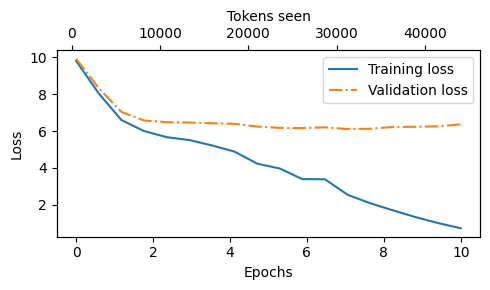

In [29]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# function to plot the loss graph and save it as PDF
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    # plt.savefig("training_loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, n_epochs, len(sample_training_losses))
plot_losses(epochs_tensor, tokens_seen, sample_training_losses, sample_validation_losses)

- Looking at the results above, we can observe that the model starts out generating incomprehensible strings of words, whereas towards the end, it's able to produce grammatically more or less correct sentences
- However, based on the training and validation set losses, we can see that the model starts overfitting
- If we were to check a few passages it writes towards the end, we would find that they are contained in the training set verbatim -- it simply memorizes the training data
- we shall use decoding strategies that can mitigate this memorization by a certain degree
- Note that the overfitting here occurs because we have a very small training set, and we iterate over it so many times

### 5.3 Decoding Strategies to control randomness

In [30]:
# inference is relatively cheap when compared to training, hence we are using "CPU"
inference_device = torch.device("cpu")

# transfering model to specified device
gpt2_model.to(inference_device)
gpt2_model.eval()

sample_text_generated = generate_text_tokens(
    model = gpt2_model,
    input_ids = text_to_token_ids(
        input_sentence = "Every effort moves you",
        tokenizer = gpt2_tokenizer
    ).to(inference_device),
    max_new_tokens = 25,
    context_window = GPT2_CONFIG_124M["contextWindow_len"]
)

print(f"Text output generated by GPT2 model is: \n{token_ids_to_text(sample_text_generated, gpt2_tokenizer)}")

Text output generated by GPT2 model is: 
Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




- Even if the `generate_text_tokens` function is executed multiple times, the LLM will always generate the same outputs
- There are two concepts, so-called decoding strategies, to modify the `generate_text_tokens`: *temperature scaling* and *top-k* sampling
- These will allow the model to control the randomness and diversity of the generated text

#### 5.3.1 Temperature Scaling

- `torch.argmax` always sampled the token with the highest probability as the next token 
- To add variety, we can sample the next token using The `torch.multinomial(probs, num_samples=1)`, sampling from a probability distribution
- Here, each index's chance of being picked corresponds to its probability in the input tensor (i.e) for toekn with 0.57 probablility will have 57% chance of being used in the generated text

In [31]:
# using argmax sampling in a sample vocabulary
sample_vocab = {
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
}

sample_inverse_vocab = {id:token for token, id in sample_vocab.items()}
# print(f"inverse vocabulary: {sample_inverse_vocab}")

# Suppose input is "every effort moves you", and the LLM
# returns the following logits for the next token:
example_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

example_token_probabilities = torch.softmax(example_token_logits, dim=-1)
print(f"softmax probabilities are: {example_token_probabilities}")

# argmax always give the token with maximum probability in the distribution as output token which is deterministic
example_tokenid = torch.argmax(example_token_probabilities, dim=-1, keepdim=True)       # token id 4(index 3) in this case
print(f"The next token generated using argmax is: {sample_inverse_vocab[example_tokenid.item()]}")

softmax probabilities are: tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])
The next token generated using argmax is: forward


In [32]:
# using multinomial distribution sampling
torch.manual_seed(123)
example_token_generated = torch.multinomial(example_token_probabilities, num_samples=1)
print(f"The next token generated using multinomial is: {sample_inverse_vocab[example_token_generated.item()]}")

The next token generated using multinomial is: forward


- Instead of determining the most likely token via `torch.argmax`, we use `torch.multinomial(probas, num_samples=1)` to determine the most likely token by sampling from the softmax distribution
- For illustration purposes, let's see what happens when we sample the next token 1,000 times using the original softmax probabilities:

In [33]:
def print_sampled_tokens(probabilities):
    torch.manual_seed(123)
    sampled_tokens = [torch.multinomial(probabilities, num_samples=1).item() for i in range(1000)]
    tokens_count = torch.bincount(torch.tensor(sampled_tokens), minlength=len(probabilities))
    for i, frequency in enumerate(tokens_count):
        print(f"{frequency} x {sample_inverse_vocab[i]}\t\t {sample_inverse_vocab[i]} occured {frequency} times in sampling")

In [34]:
print_sampled_tokens(example_token_probabilities)

73 x closer		 closer occured 73 times in sampling
0 x every		 every occured 0 times in sampling
0 x effort		 effort occured 0 times in sampling
582 x forward		 forward occured 582 times in sampling
2 x inches		 inches occured 2 times in sampling
0 x moves		 moves occured 0 times in sampling
0 x pizza		 pizza occured 0 times in sampling
343 x toward		 toward occured 343 times in sampling
0 x you		 you occured 0 times in sampling


- We can control the distribution and selection process via a concept called temperature scaling
- "Temperature scaling" is just a fancy word for dividing the logits by a number greater than 0
- Temperatures greater than 1 will result in more uniformly distributed token probabilities after applying the softmax
- Temperatures smaller than 1 will result in more confident (sharper or more peaky) distributions after applying the softmax

In [35]:
def softmax_with_temperature(logits, temperature):
    logits_with_temperature = logits / temperature
    return torch.softmax(logits_with_temperature, dim=-1)

In [36]:
# temperature values
temperatures = [1, 0.1, 5]

scaled_probabilities = [softmax_with_temperature(example_token_logits, T) for T in temperatures]

# print the probabilities generated for different temperature values
for i in range(len(temperatures)):
    print(f"Softmax probabilities when temperature valus is {temperatures[i]}: {scaled_probabilities[i]}")

Softmax probabilities when temperature valus is 1: tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])
Softmax probabilities when temperature valus is 0.1: tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22])
Softmax probabilities when temperature valus is 5: tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])


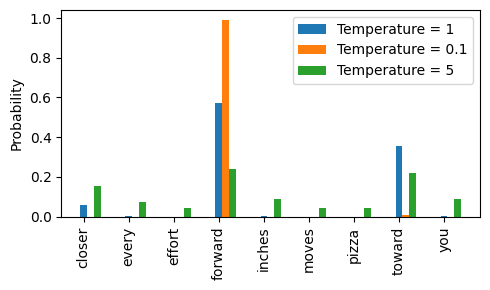

In [37]:
# bar plot showing probabilities of each token with different temperature values
x = torch.arange(len(sample_vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probabilities[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(sample_vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
# plt.savefig("temperature-plot.pdf")
plt.show()

In [38]:
# printing occurance of tokens with differnt temperature value for sampling 1000 times
for i in range(len(temperatures)):
    print(f"Token occurences for temperature value {temperatures[i]} is:")
    print_sampled_tokens(scaled_probabilities[i])
    print(f"-"*50)

Token occurences for temperature value 1 is:
73 x closer		 closer occured 73 times in sampling
0 x every		 every occured 0 times in sampling
0 x effort		 effort occured 0 times in sampling
582 x forward		 forward occured 582 times in sampling
2 x inches		 inches occured 2 times in sampling
0 x moves		 moves occured 0 times in sampling
0 x pizza		 pizza occured 0 times in sampling
343 x toward		 toward occured 343 times in sampling
0 x you		 you occured 0 times in sampling
--------------------------------------------------
Token occurences for temperature value 0.1 is:
0 x closer		 closer occured 0 times in sampling
0 x every		 every occured 0 times in sampling
0 x effort		 effort occured 0 times in sampling
985 x forward		 forward occured 985 times in sampling
0 x inches		 inches occured 0 times in sampling
0 x moves		 moves occured 0 times in sampling
0 x pizza		 pizza occured 0 times in sampling
15 x toward		 toward occured 15 times in sampling
0 x you		 you occured 0 times in sampli

- From above output, we can observe that the rescaling via temperature 0.1 results in a sharper distribution, approaching `torch.argmax`, such that the most likely word is almost always selected
- While rescaling probabilities via temperature 5, the probablities are more uniformly distributed but assuming an LLM input "every effort moves you", using higher temperature value can sometimes result in nonsensical texts, such as "every effort moves you pizza" which has probability of occuring 3.2% of the time (32 out of 1000 times)

#### 5.3.2 Top K sampling

- To be able to use higher temperatures to increase output diversity and to reduce the probability of nonsensical sentences, we can restrict the sampled tokens to the top-k most likely tokens as shown below:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/15.webp" width=500px>

In [39]:
# implementing top k with value 3(vocabulary size: 9)
top_k = 3
# torch library has topk function which takes a tensor (preferably `logits`) and integer(top K defined) as input and 
# returns two tensors one with values of top k logits(sorted in desc order) and another tensor with their index values
topK_logits, topK_indices = torch.topk(example_token_logits, k=top_k)
print(f"The top K logits are: {topK_logits}\n"
      f"The corresponding indices are: {topK_indices}")

The top K logits are: tensor([6.7500, 6.2800, 4.5100])
The corresponding indices are: tensor([3, 7, 0])


In [40]:
# now converting the remaining values as `-inf` to discard tehm from sampling
sampled_topK = torch.where(
    condition = example_token_logits < topK_logits[-1],     # finding the logits which are less than the minimum value of top K logits
    input = torch.tensor(-torch.inf),                       # setting the reamining logits values to `-inf`
    other = example_token_logits                            # leaving top K logits values as it is
)

print(f"The top K samples logits are: {sampled_topK}")

# calculating softmax for the top K sampled logits 
softmax_topK = torch.softmax(sampled_topK, dim=-1)
print(f"The softmax values for samples top K logits are: {softmax_topK}")

The top K samples logits are: tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
The softmax values for samples top K logits are: tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


NOTE: An alternative, slightly more efficient implementation of the previous code cell is the following:

> ```python
> sampled_topK = torch.full_like( # create tensor containing -inf values 
>    example_token_logits, -torch.inf
>)   
> sampled_topK[topK_indices] = example_token_logits[topK_indices] # copy top k values into the -inf tensor
> ```

For more details, see https://github.com/rasbt/LLMs-from-scratch/discussions/326


#### 5.3.3 Modifying text generation function

In [41]:
def generate_tokens_with_sampling(model, input_ids, max_new_tokens, context_window, top_k = None, temperature = 0.0, eos_id = None):
    # input_ids is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10 then only the last 5 tokens are used as context
        ids_context_size = input_ids[:, -context_window:]

        with torch.no_grad():
            logits = model(ids_context_size)
        
        # Focus only on the last token
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Filter top k values from the logits
        if top_k is not None:
            topK_logits, topK_indices = torch.topk(logits, k=top_k)
            minimum_value = topK_logits[:, -1]
            logits = torch.where(
                condition = logits < minimum_value,
                input = torch.tensor(-torch.inf),
                other = logits
            )
        
        # apply temperature scaling
        if temperature > 0.0:
            scaled_logits = logits / temperature
            probabilities = torch.softmax(scaled_logits, dim=-1)
            next_id = torch.multinomial(probabilities, num_samples=1)

        else:
            # Get the idx of the vocab entry with the highest probability value
            next_id = torch.argmax(logits, dim=-1, keepdim=True)     # (batch, 1)
        
        # if the next token generated is qual to end of sequence defined, then stop the text generation process
        if next_id == eos_id:
            break

        # Append sampled index to the running sequence
        input_ids = torch.cat((input_ids, next_id), dim=-1)   # (batch, n_tokens+1)
        
    return input_ids

In [42]:
torch.manual_seed(123)

sample_text_generated = generate_tokens_with_sampling(
    model = gpt2_model,
    input_ids = text_to_token_ids(
        input_sentence = "Every effort moves you",
        tokenizer = gpt2_tokenizer
    ).to(inference_device),
    max_new_tokens = 25,
    context_window = GPT2_CONFIG_124M["contextWindow_len"],
)

print(f"Text output generated by GPT2 model without temperature and top K is: \n{token_ids_to_text(sample_text_generated, gpt2_tokenizer)}")

Text output generated by GPT2 model without temperature and top K is: 
Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [43]:
torch.manual_seed(123)

sample_text_generated = generate_tokens_with_sampling(
    model = gpt2_model,
    input_ids = text_to_token_ids(
        input_sentence = "Every effort moves you",
        tokenizer = gpt2_tokenizer
    ).to(inference_device),
    max_new_tokens = 15,
    context_window = GPT2_CONFIG_124M["contextWindow_len"],
    top_k = 25,
    temperature = 1.4
)

print(f"Text output generated by GPT2 model with temperature and top K is: \n{token_ids_to_text(sample_text_generated, gpt2_tokenizer)}")

Text output generated by GPT2 model with temperature and top K is: 
Every effort moves you?" I turned to surprise. Th--I felt nervous portrait--had enough


### 5.4 Saving and loading model weights

- The recommended way in PyTorch is to save the model weights, the so-called `state_dict` via by applying the `torch.save` function to the `.state_dict()` method

In [44]:
# torch function to save the model weights in a file(the file can contain any extension, `pth` is commonly used)
torch.save(gpt2_model.state_dict(), "gpt2_model.pth")

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")

# creating a placeholder LLM architecture with random weights where the weights will be loaded 
torch.manual_seed(123)
gpt2_model_load = GPTModel(GPT2_CONFIG_124M)

gpt2_model_load.eval();

In [ ]:
# random weights initialized 
print(f"Token embedding layer weights {gpt2_model_load.token_embedding_layer.weight}")

Token embedding layer weights Parameter containing:
tensor([[ 3.3737e-01, -1.7778e-01, -3.0353e-01,  ..., -3.1812e-01,
         -1.3936e+00,  5.2262e-01],
        [ 2.5787e-01,  3.4197e-01, -8.1678e-01,  ..., -4.0981e-01,
          4.9785e-01, -3.7207e-01],
        [ 7.9574e-01,  5.3501e-01,  9.4275e-01,  ..., -1.0749e+00,
          9.5492e-02, -1.4138e+00],
        ...,
        [-7.1278e-01, -5.0190e-01,  1.4119e+00,  ..., -1.4979e-01,
         -4.8977e-01, -1.0620e+00],
        [ 2.0646e+00,  1.1190e+00,  3.8486e-01,  ..., -7.2015e-01,
         -5.5703e-01,  9.8639e-01],
        [ 1.1364e-03, -7.5320e-01, -1.7924e-01,  ..., -3.2443e-01,
          2.6055e-01,  5.8885e-01]], requires_grad=True)


In [49]:
# loading weights from saved file into model architecture
gpt2_model_load.load_state_dict(torch.load("gpt2_model.pth", map_location = device, weights_only = True))

<All keys matched successfully>

In [50]:
# weights after loading 
print(f"Token embedding layer weights {gpt2_model_load.token_embedding_layer.weight}")

Token embedding layer weights Parameter containing:
tensor([[ 3.4348e-01, -1.8181e-01, -3.0181e-01,  ..., -3.1942e-01,
         -1.3886e+00,  5.2595e-01],
        [ 2.6023e-01,  3.3989e-01, -8.2047e-01,  ..., -4.0618e-01,
          4.9582e-01, -3.6972e-01],
        [ 7.9288e-01,  5.3309e-01,  9.3936e-01,  ..., -1.0710e+00,
          9.5149e-02, -1.4087e+00],
        ...,
        [-7.1022e-01, -5.0010e-01,  1.4068e+00,  ..., -1.4925e-01,
         -4.8801e-01, -1.0582e+00],
        [ 2.0572e+00,  1.1150e+00,  3.8348e-01,  ..., -7.1757e-01,
         -5.5503e-01,  9.8285e-01],
        [ 1.1323e-03, -7.5050e-01, -1.7859e-01,  ..., -3.2327e-01,
          2.5962e-01,  5.8674e-01]], requires_grad=True)


- It's common to train LLMs with adaptive optimizers like Adam or AdamW instead of regular SGD
- These adaptive optimizers store additional parameters for each model weight, so it makes sense to save them as well in case we plan to continue the pretraining later:

In [52]:
# saving model and optimizer parameters
torch.save({
    "gpt2_model_state_dict": gpt2_model.state_dict(),
    "gpt2_optimizer_state_dict": adam_optimizer.state_dict()
}, "gpt2_model_with_optimizer.pth")

In [61]:
# loading model and optimizer from saved pickle file
checkpoint = torch.load("gpt2_model_with_optimizer.pth", map_location=device, weights_only=True)

gpt2_model_load.load_state_dict(checkpoint["gpt2_model_state_dict"])

torch.manual_seed(123)
gpt2_optimizer_load = torch.optim.AdamW(gpt2_model_load.parameters(), lr = 0.005, weight_decay=0.001)
print(f"Learning rate before loading weights: {gpt2_optimizer_load.param_groups[0].__getitem__("lr")}")

Learning rate before loading weights: 0.005


In [62]:
gpt2_optimizer_load.load_state_dict(checkpoint["gpt2_optimizer_state_dict"])
print(f"Learning rate after loading weights: {gpt2_optimizer_load.param_groups[0].__getitem__("lr")}")

Learning rate after loading weights: 0.0004


### 5.5 Loading pre-trained weights by OpenAI 

- First, some boilerplate code to download the files from OpenAI and load the weights into Python
- Since OpenAI used [TensorFlow](https://www.tensorflow.org/), we will have to install and use TensorFlow for loading the weights; [tqdm](https://github.com/tqdm/tqdm) is a progress bar library for visualizing progress of download

In [ ]:
# install tensorflow and tqdm
# pip install tensorflow tqdm

'2.20.0'

In [66]:
print(f"Tensorflow version: {version("tensorflow")}")
print(f"tqdm version: {version("tqdm")}")

Tensorflow version: 2.20.0
tqdm version: 4.67.1


In [67]:
from openai_gpt2_download import download_and_load_gpt2

settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

checkpoint: 100%|██████████| 77.0/77.0 [00:00<?, ?iB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:02<00:00, 398kiB/s] 
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 90.0kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [03:43<00:00, 2.22MiB/s]   
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 2.59MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 245kiB/s]  
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 275kiB/s]  


In [70]:
print(f"Settings for GPT2 model are: {settings}")
print(f"Parameters for GPT2 model are: {params.keys()}")

Settings for GPT2 model are: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameters for GPT2 model are: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [71]:
# printing weights present in token embedding layer
print(f"The shape of the token embedding layer is: {params["wte"].shape}")
print(f"Weights in token embedding layer is: {params["wte"]}")

The shape of the token embedding layer is: (50257, 768)
Weights in token embedding layer is: [[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]


- Alternatively, "355M", "774M", and "1558M" are also supported `model_size` arguments
- The difference between these differently sized models is summarized in the figure below:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/17.webp" width=500px>

- Above, we loaded the 124M GPT-2 model weights into Python, however we still need to transfer them into our `GPTModel` instance
- First, we initialize a new GPTModel instance
- Note that the original GPT model initialized the linear layers for the query, key, and value matrices in the multi-head attention module with bias vectors, which is not required or recommended; however, to be able to load the weights correctly, we have to enable these too by setting `qkv_bias` to `True` in our implementation, too
- We are also using the `1024` token context length that was used by the original GPT-2 model(s)

In [113]:
GPT2_CONFIG_124M

{'vocab_size': 50257,
 'contextWindow_len': 256,
 'embedding_dim': 768,
 'num_heads': 12,
 'num_transformerLayers': 12,
 'dropout_rate': 0.1,
 'qkv_bias': False}

In [114]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"embedding_dim": 768, "num_transformerLayers": 12, "num_heads": 12},
    "gpt2-medium (355M)": {"embedding_dim": 1024, "num_transformerLayers": 24, "num_heads": 16},
    "gpt2-large (774M)": {"embedding_dim": 1280, "num_transformerLayers": 36, "num_heads": 20},
    "gpt2-xl (1558M)": {"embedding_dim": 1600, "num_transformerLayers": 48, "num_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT2_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"contextWindow_len": 1024, "qkv_bias": True})

gpt2_124m = GPTModel(NEW_CONFIG)
gpt2_124m.eval();

In [74]:
# utility function which converts tensorflow weights into pytorch trainable parameters
def assign_tf_torch(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [136]:
import numpy as np

def load_weights_into_gpt_instance(gptInstance, params):
    # assign embedding layer parameter weights
    gptInstance.token_embedding_layer.weight = assign_tf_torch(
        gptInstance.token_embedding_layer.weight, 
        params["wte"]
    )
    gptInstance.position_embedding_layer.weight = assign_tf_torch(
        gptInstance.position_embedding_layer.weight, 
        params["wpe"]
    )
    
    # assign transformer block parameter weights
    for b in range(len(params["blocks"])):
        # MHA layer paramters
        # GPT2 uses a combined qkv weight matrix which needs to be split inorder to load weights
        q_W, k_W, v_W = np.split(
            params["blocks"][b]["attn"]["c_attn"]["w"], indices_or_sections=3, axis=-1
        )
        # W_queries weight params
        gptInstance.transformer_blocks[b].attention_layer.W_queries.weight = assign_tf_torch(
            gptInstance.transformer_blocks[b].attention_layer.W_queries.weight, 
            q_W.T
        )
        # W_keys weight params
        gptInstance.transformer_blocks[b].attention_layer.W_keys.weight = assign_tf_torch(
            gptInstance.transformer_blocks[b].attention_layer.W_keys.weight, 
            k_W.T
        )
        # W_values weight params
        gptInstance.transformer_blocks[b].attention_layer.W_values.weight = assign_tf_torch(
            gptInstance.transformer_blocks[b].attention_layer.W_values.weight, 
            v_W.T
        )

        # bias
        # GPT2 uses a combined qkv bias matrix which needs to be split inorder to load bias
        q_b, k_b, v_b = np.split(
            params["blocks"][b]["attn"]["c_attn"]["b"], indices_or_sections=3, axis=-1
        )
        # W_queries bias params
        gptInstance.transformer_blocks[b].attention_layer.W_queries.bias = assign_tf_torch(
            gptInstance.transformer_blocks[b].attention_layer.W_queries.bias,
            q_b
        )
        # W_keys bias params
        gptInstance.transformer_blocks[b].attention_layer.W_keys.bias = assign_tf_torch(
            gptInstance.transformer_blocks[b].attention_layer.W_keys.bias,
            k_b
        )
        # W_values bias params
        gptInstance.transformer_blocks[b].attention_layer.W_values.bias = assign_tf_torch(
            gptInstance.transformer_blocks[b].attention_layer.W_values.bias,
            v_b
        )

        # projection layer weight and bias
        gptInstance.transformer_blocks[b].attention_layer.projection.weight = assign_tf_torch(
            gptInstance.transformer_blocks[b].attention_layer.projection.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T
        )
        gptInstance.transformer_blocks[b].attention_layer.projection.bias = assign_tf_torch(
            gptInstance.transformer_blocks[b].attention_layer.projection.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"]
        )

        # LayerNorm1 scale(g) and shift(b) parameters
        gptInstance.transformer_blocks[b].layerNorm1.scale = assign_tf_torch(
           gptInstance.transformer_blocks[b].layerNorm1.scale,
           params["blocks"][b]["ln_1"]["g"]
        )
        gptInstance.transformer_blocks[b].layerNorm1.shift = assign_tf_torch(
           gptInstance.transformer_blocks[b].layerNorm1.shift,
           params["blocks"][b]["ln_1"]["b"]
        )

        # LayerNorm2 scale(g) and shift(b) parameters
        gptInstance.transformer_blocks[b].layerNorm2.scale = assign_tf_torch(
           gptInstance.transformer_blocks[b].layerNorm2.scale,
           params["blocks"][b]["ln_2"]["g"]
        )
        gptInstance.transformer_blocks[b].layerNorm2.shift = assign_tf_torch(
           gptInstance.transformer_blocks[b].layerNorm2.shift,
           params["blocks"][b]["ln_2"]["b"]
        )

        # Feed forward layer weight and bias paramters
        # Linear layer 1
        gptInstance.transformer_blocks[b].feedForward_layer.layers[0].weight = assign_tf_torch(
            gptInstance.transformer_blocks[b].feedForward_layer.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T
        )
        gptInstance.transformer_blocks[b].feedForward_layer.layers[0].bias = assign_tf_torch(
            gptInstance.transformer_blocks[b].feedForward_layer.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"]
        )
        # Linear layer 2
        gptInstance.transformer_blocks[b].feedForward_layer.layers[2].weight = assign_tf_torch(
            gptInstance.transformer_blocks[b].feedForward_layer.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T
        )
        gptInstance.transformer_blocks[b].feedForward_layer.layers[2].bias = assign_tf_torch(
            gptInstance.transformer_blocks[b].feedForward_layer.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"]
        )
    
    # assign parameters to final layer norm
    gptInstance.final_norm.scale = assign_tf_torch(
        gptInstance.final_norm.scale,
        params["g"]
    )
    gptInstance.final_norm.shift = assign_tf_torch(
       gptInstance.final_norm.shift,
       params["b"]
    )

    # assign parameters to final output_head layer
    gptInstance.output_head.weight = assign_tf_torch(
        gptInstance.output_head.weight,
        params["wte"]
    )

- Note: the weight matrices are transposed in openAI weights hence `.T` is used for proper mapping
- It won't raise ValueError since they are (n x n) matrices in attention layer where n is embedding dimension, but the model produces irrelevant output since the wweights are loaded incorectly

In [137]:
load_weights_into_gpt_instance(gptInstance=gpt2_124m, params=params)

In [138]:
torch.manual_seed(123)
gpt2_124m.to(inference_device)
gpt2_124m.eval()

gpt2_generated_text = generate_tokens_with_sampling(
    model = gpt2_124m,
    input_ids = text_to_token_ids(
        input_sentence = "Every effort moves you",
        tokenizer = gpt2_tokenizer
    ).to(inference_device),
    max_new_tokens = 25,
    context_window = NEW_CONFIG["contextWindow_len"],
    top_k=50,
    temperature=1.5
)

print(f"Text output generated by GPT2 model is: \n{token_ids_to_text(gpt2_generated_text, gpt2_tokenizer)}")

Text output generated by GPT2 model is: 
Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?




- We know that we loaded the model weights correctly because the model can generate coherent text, if we made even a small mistake, the model would not be able to do that